In [38]:
import os
import tensorflow as tf
import pandas as pd
import sys
import matplotlib.pyplot as plt
from itertools import permutations, combinations
from matplotlib import rcParams, cycler
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc7 import *

In [39]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [40]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [41]:
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))
perm_combos[0,0,1]

array([0, 2, 1])

In [42]:
# Make the permutation matrices
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))#.transpose(0,2,3,1)

perm_combos = tf.one_hot(
    perm_combos,
    3,
    axis=-1,
)
perm_combos = tf.transpose(perm_combos, (0,1,2,4,3))

perm_combos = tf.where(perm_combos == 1.0, 
                  tf.ones_like(perm_combos) * 10.0,   # large positive
                  tf.ones_like(perm_combos) * -10.0)  # large negative

In [43]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [44]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [45]:
model = SGCCircuit(bounds = param_bounds, enforce_permutation=perm_combos[:10])
model.initialize_random_parameters(2,3,10)
dlgn_params = model.dlgn_scaled

In [49]:
D = dlgn_params[:,:,:,:,0,0]
D = tf.transpose(D, (0,3,1,2))[:,:,:,None,:]
D = tf.squeeze(tf.matmul(D, perm_combos[:10]))
#D = tf.transpose(D, (0,2,3,1))[:,:,:,:,None,None]

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

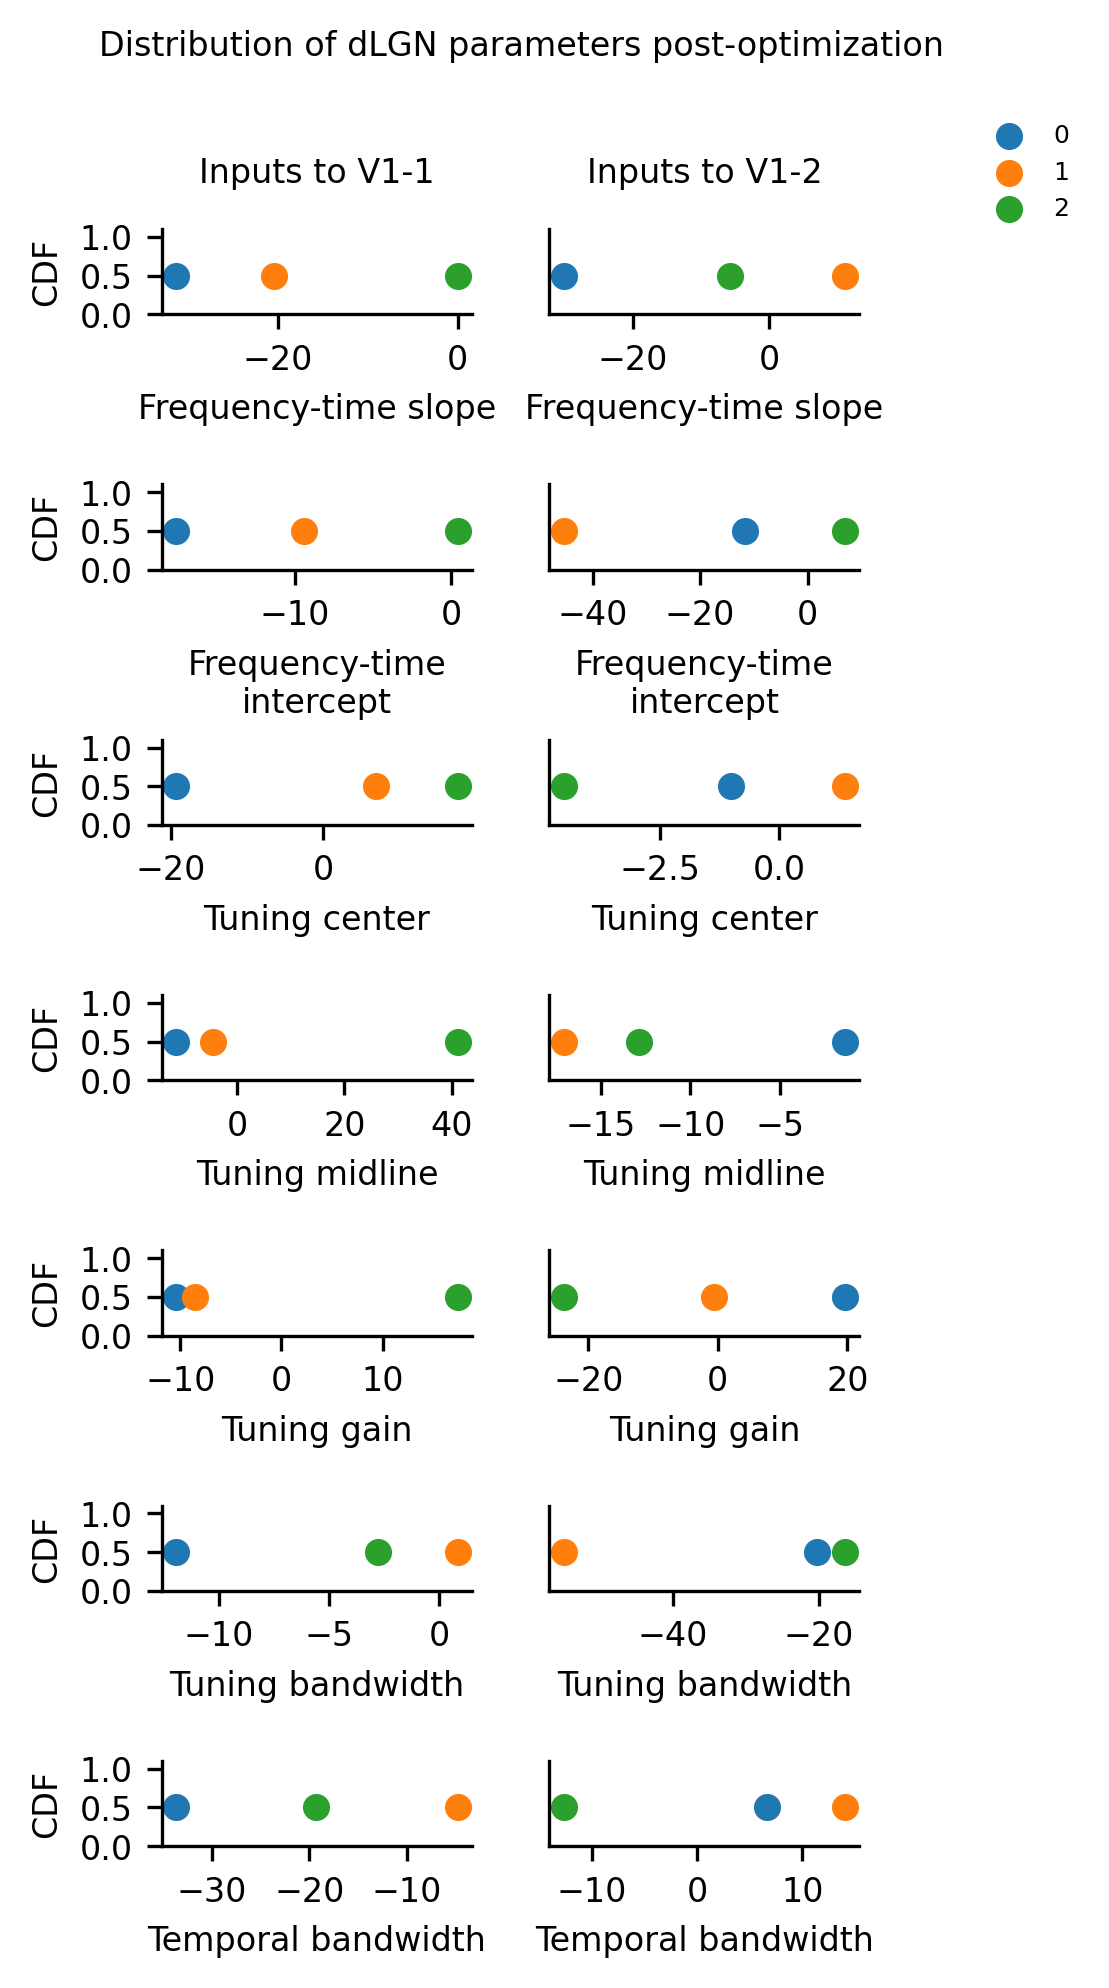

In [51]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(D[0, row, u, i], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [ ]:
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

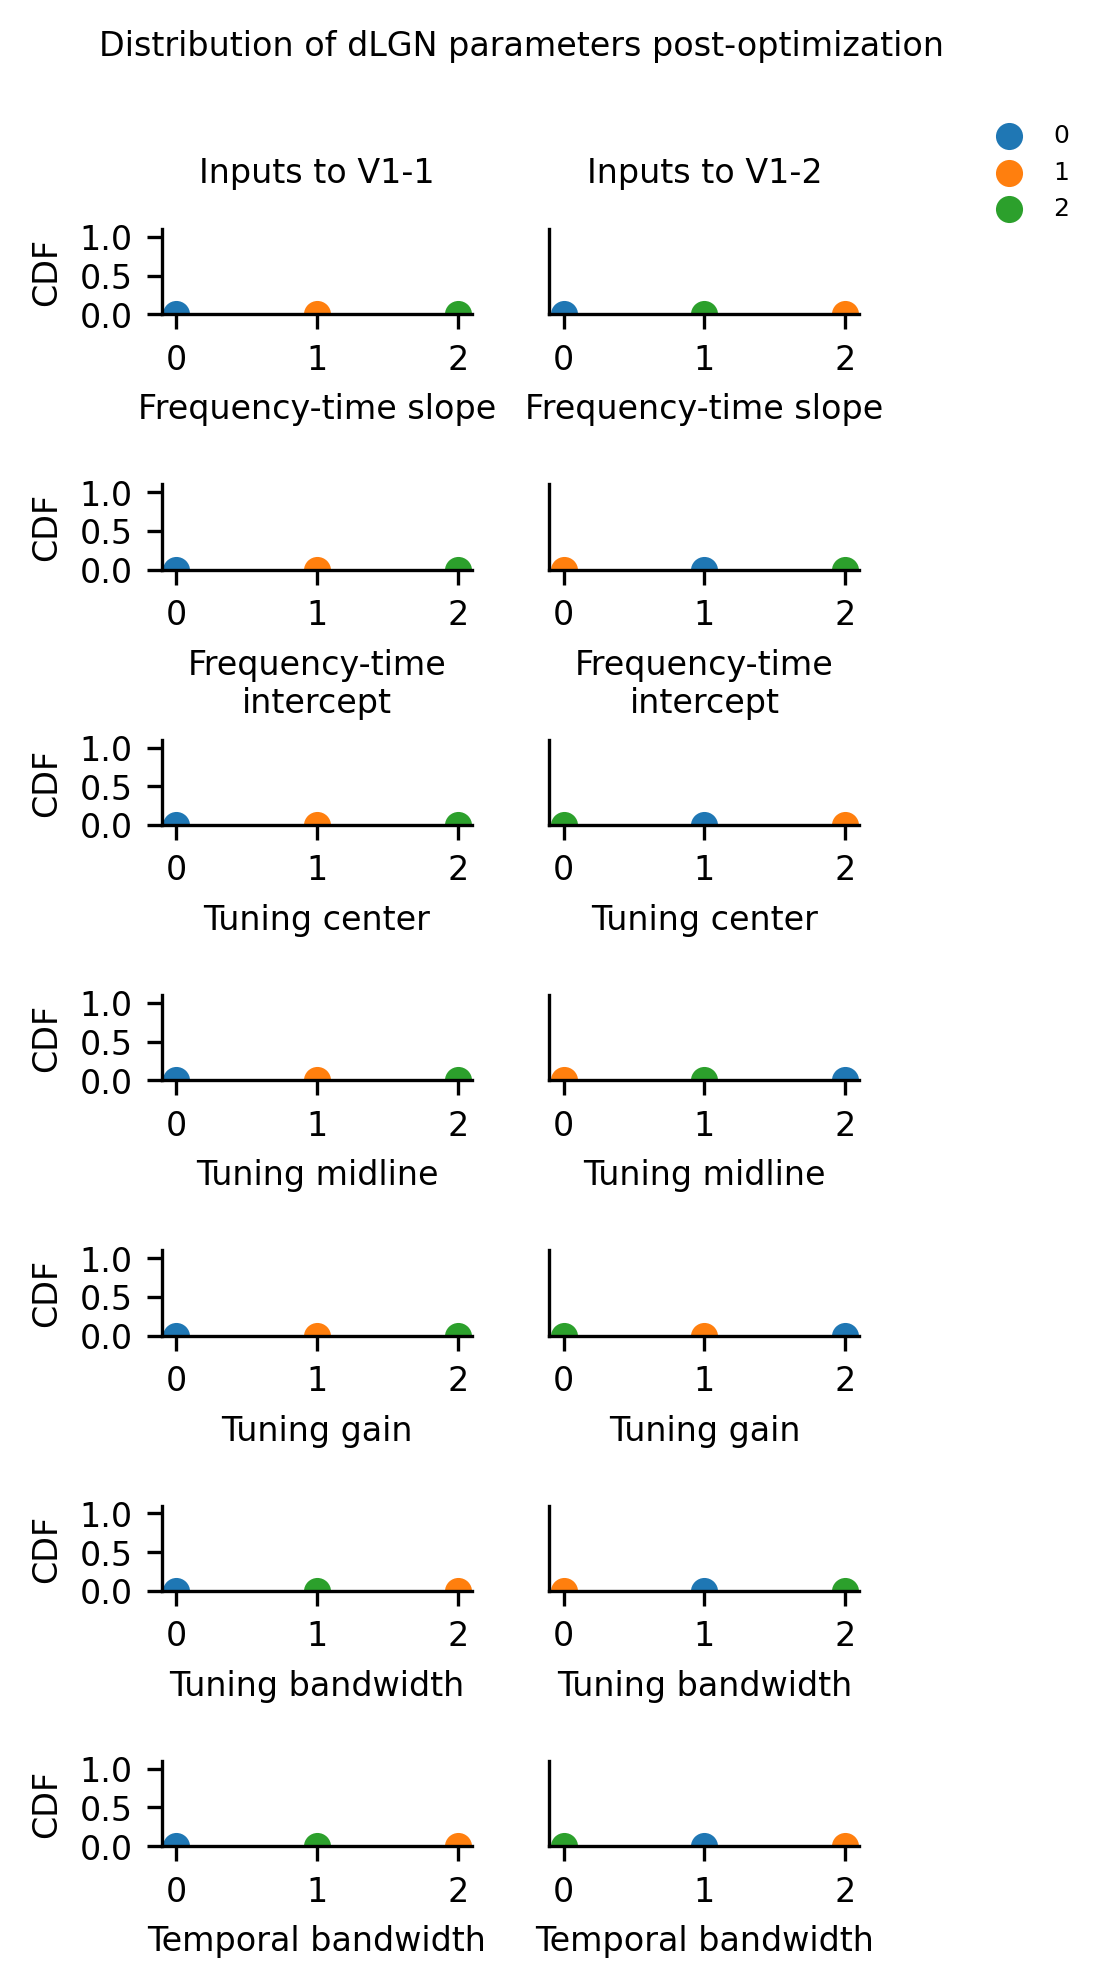

In [ ]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(perm_combos[0, row, u, i], [0], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [ ]:
# Make the permutation matrices
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))#.transpose(0,2,3,1)

perm_combos = tf.one_hot(
    perm_combos,
    3,
    axis=-1,
)

perm_combos = tf.where(perm_combos == 1.0, 
                  tf.ones_like(perm_combos) * 10.0,   # large positive
                  tf.ones_like(perm_combos) * -10.0)  # large negative

In [ ]:
model2 = SGCCircuit(bounds = param_bounds, enforce_permutation=perm_combos[:10])
model2.load_saved_parameters(optimizer1.outputs['final_epoch_params'])

NameError: name 'optimizer1' is not defined

In [ ]:
optimizer2 = Optimize(model2, epochs=100)
optimizer2.fit(X,Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000019A727E2910>
Training step = 0, N_exploration_samples = 10,
min_loss = 3.933516025543213
med_loss = 8.730587005615234
max_loss = 19.815725326538086



<tf.Tensor: shape=(100, 10), dtype=float16, numpy=
array([[14.7  ,  5.203, 19.81 ,  8.24 ,  9.22 ,  9.4  , 11.836,  3.934,
         7.6  ,  5.414],
       [14.66 ,  5.188, 19.77 ,  8.22 ,  9.19 ,  9.37 , 11.805,  3.92 ,
         7.582,  5.395],
       [14.62 ,  5.17 , 19.7  ,  8.195,  9.16 ,  9.336, 11.766,  3.904,
         7.566,  5.375],
       [14.57 ,  5.156, 19.66 ,  8.164,  9.125,  9.305, 11.734,  3.89 ,
         7.55 ,  5.355],
       [14.53 ,  5.14 , 19.6  ,  8.14 ,  9.09 ,  9.27 , 11.7  ,  3.877,
         7.53 ,  5.336],
       [14.484,  5.125, 19.55 ,  8.12 ,  9.06 ,  9.24 , 11.67 ,  3.863,
         7.516,  5.316],
       [14.44 ,  5.11 , 19.48 ,  8.09 ,  9.03 ,  9.22 , 11.64 ,  3.848,
         7.5  ,  5.297],
       [14.4  ,  5.094, 19.42 ,  8.07 ,  9.01 ,  9.19 , 11.61 ,  3.834,
         7.484,  5.277],
       [14.35 ,  5.08 , 19.38 ,  8.05 ,  8.98 ,  9.16 , 11.58 ,  3.82 ,
         7.465,  5.258],
       [14.31 ,  5.062, 19.31 ,  8.02 ,  8.945,  9.125, 11.55 ,  3.807,
    

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

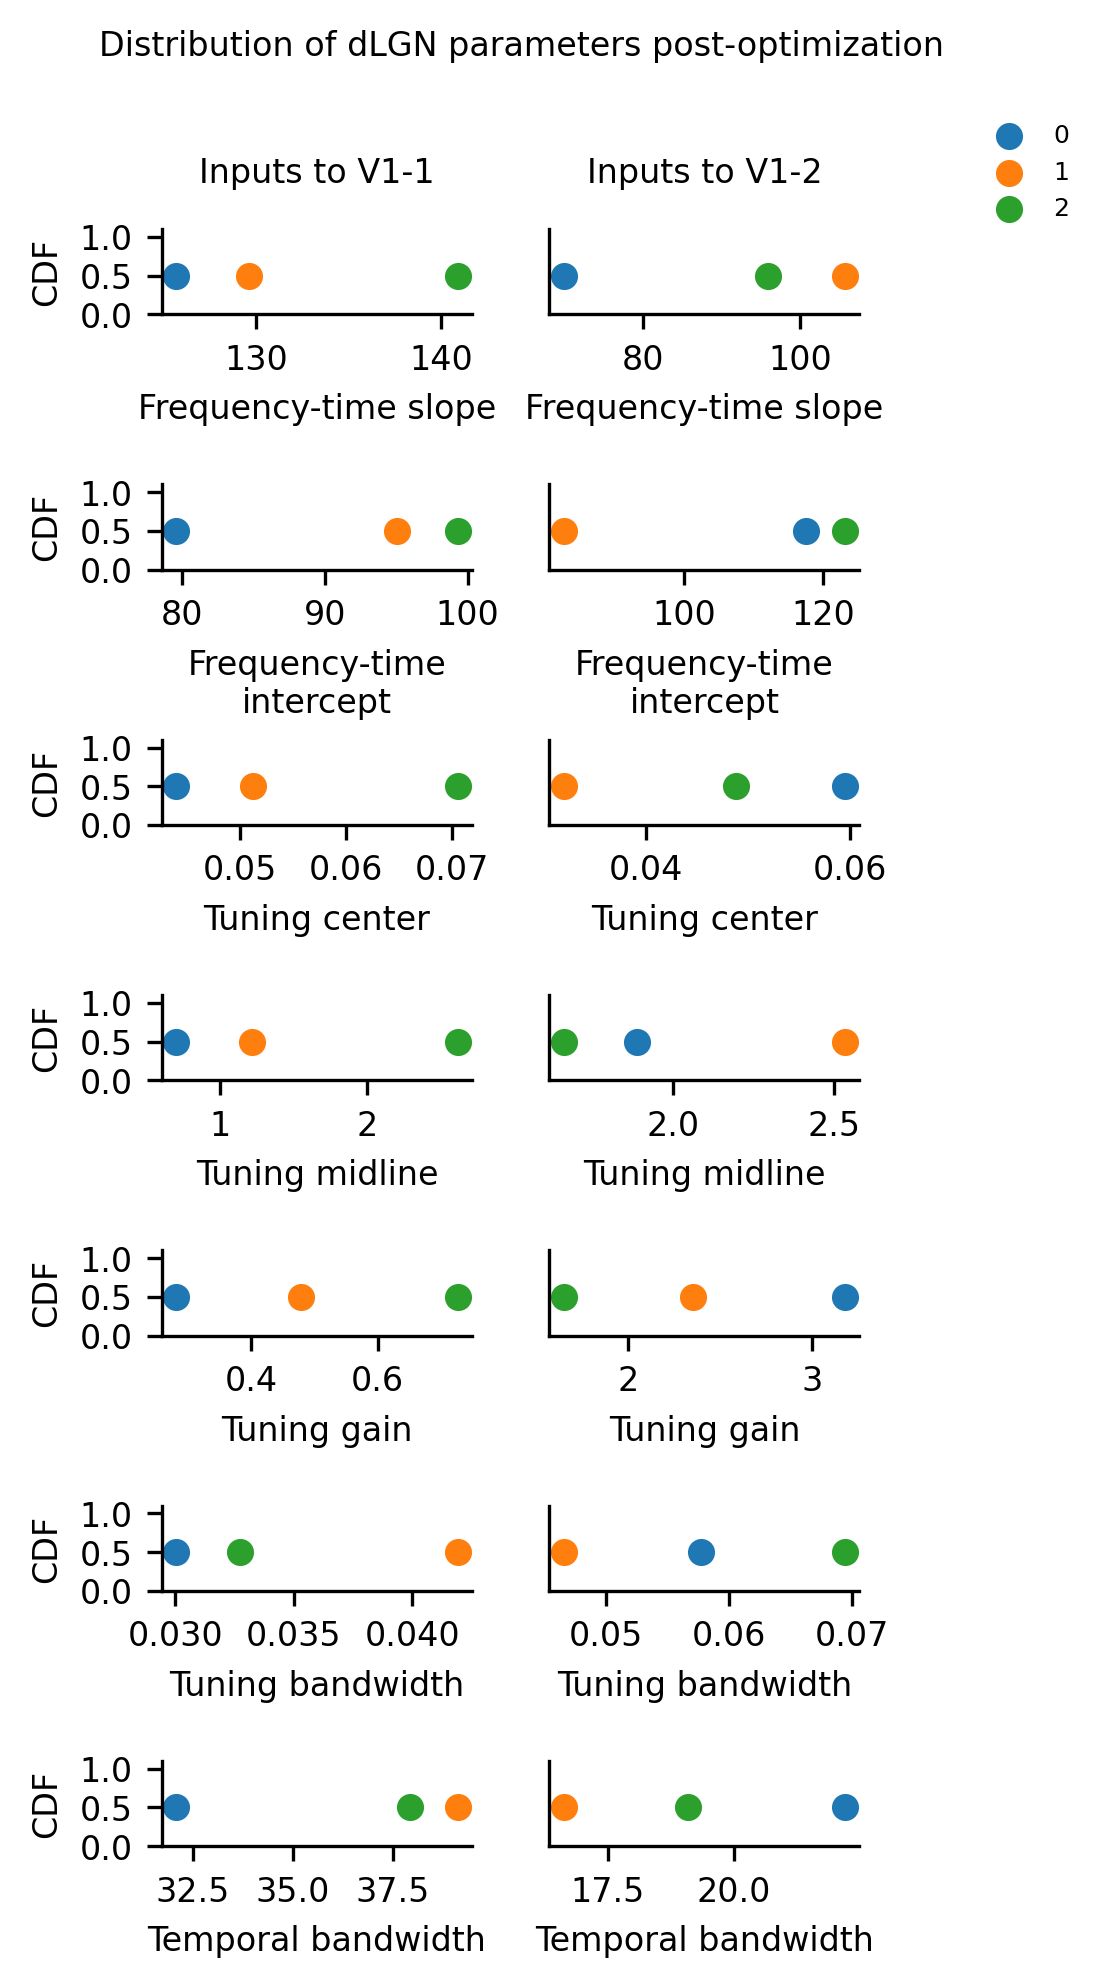

In [ ]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model2.params['dLGN_params'][0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [ ]:
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

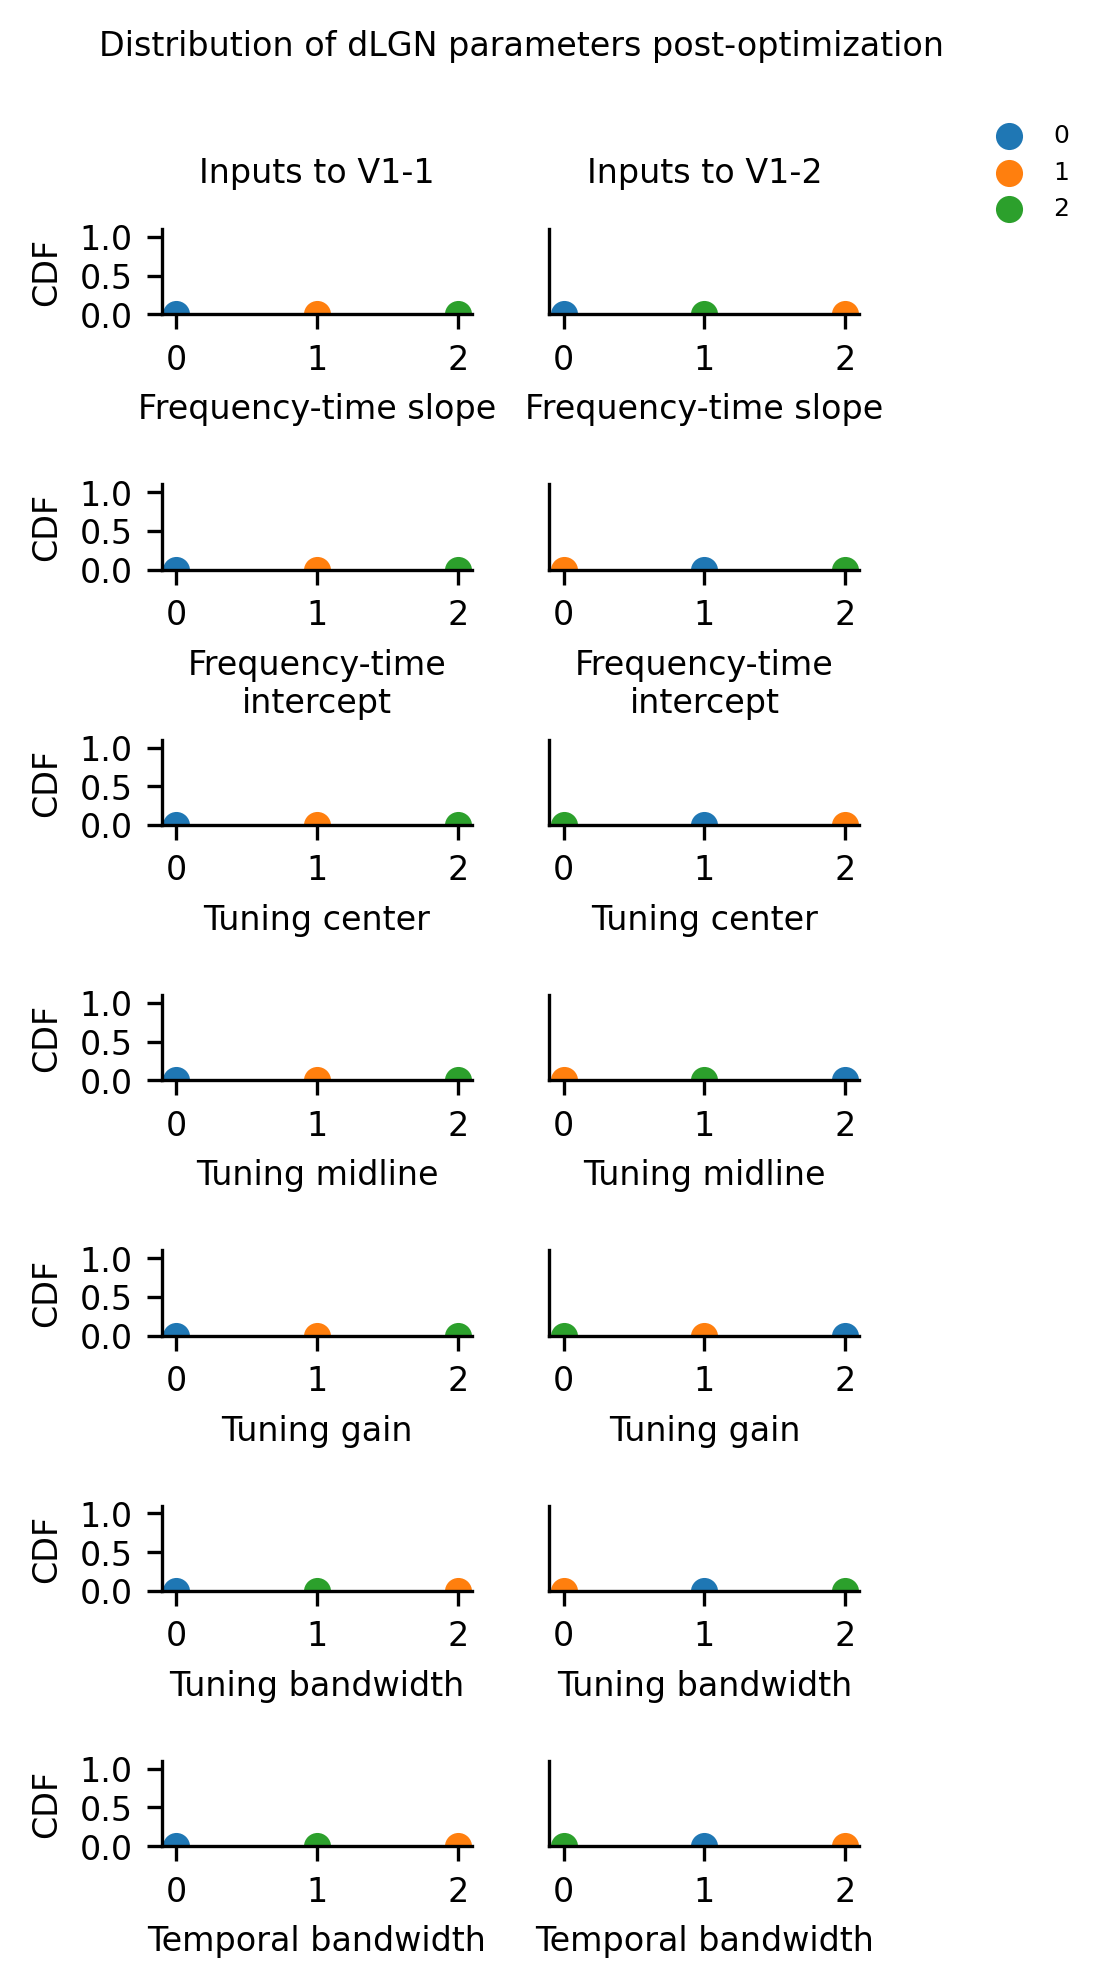

In [ ]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(perm_combos[0, row, u, i], [0], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)
